# RQ3: Predictor Stability Analysis

**Research Question**  
Do core variables (BMI, smoking, exercise, income, education) retain predictive power across the entire decade?

- H3₀: No significant variation in predictor strength across 2015–2024  
- H3₁: At least one predictor shows significant variation in influence

In [1]:
from pathlib import Path
from typing import Union, Optional
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
import logging

warnings.filterwarnings("ignore")

# Plotting style
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# Configure Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

In [2]:
BASE_DIR = Path.cwd().parent 
PROCESSED_DATA_DIR = BASE_DIR / "data_processed"
REPORTS_DIR = BASE_DIR / "reports"
CONFIG_DIR = BASE_DIR / "config"
BRFSS_CLEAN_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024_cleaned.zip"
BRFSS_RECODDED_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024_recoded.zip"

# Ensure directories exist
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def read_zipped_csv(
    zip_path: Union[str, Path],
    **read_csv_kwargs
) -> pd.DataFrame:
    """
    Read a single-CSV .zip file into a pandas DataFrame.

    Parameters
    ----------
    zip_path : str or Path
        Path to the .zip file (containing exactly one CSV, or a CSV
        with the same name as the zip).
    **read_csv_kwargs :
        Any extra keyword args passed through to pandas.read_csv
        (e.g. sep, dtype, parse_dates).

    Returns
    -------
    pd.DataFrame
    """
    zip_path = Path(zip_path)
    # For a single CSV in the zip, this is enough:
    return pd.read_csv(zip_path, compression="zip", **read_csv_kwargs)

In [4]:
df_raw = read_zipped_csv(BRFSS_RECODDED_ZIP_FILE)
logging.info(f"Initial data loaded with {df_raw.shape[0]} rows. and columns: {df_raw.shape[1]}")

2026-02-04 23:20:26 - INFO - Initial data loaded with 2489586 rows. and columns: 19


In [5]:
def prepare_features(df: pd.DataFrame):
    """
    Prepare feature set for modeling.
    
    Core predictors: BMICAT, EXERCISE, SMOKER, INCOME, EDUCATION_LEVEL, etc.
    """
    # Core predictors as per RQ3
    feature_cols = [
        "BMICAT",
        "EXERCISE",
        "SMOKER",
        "INCOME",
        "EDUCATION_LEVEL",
        "AGE_CATEGORIES",
        "SEX",
        "HEALTH_CARE_COVERAGE",
        "HEALTH_STATUS",
        "POOR_PHYSICAL_HEALTH_DAYS",
    ]
    
    # Filter to valid data
    df_clean = df[df["DIABETES"].isin([0, 1])].copy()
    
    # Remove rows with missing values in key columns
    for col in feature_cols:
        if col in df_clean.columns:
            df_clean = df_clean[df_clean[col].notna()]
    
    return df_clean, feature_cols

# Adjust path as needed
df = read_zipped_csv(BRFSS_CLEAN_ZIP_FILE)
df_clean, feature_cols = prepare_features(df)

logging.info(f"✓ Loaded {len(df):,} total records")
logging.info(f"✓ Clean data: {len(df_clean):,} records")
logging.info(f"✓ Features: {len(feature_cols)}")
logging.info(f"  {', '.join(feature_cols)}")

2026-02-04 23:20:30 - INFO - ✓ Loaded 2,489,586 total records
2026-02-04 23:20:30 - INFO - ✓ Clean data: 2,489,586 records
2026-02-04 23:20:30 - INFO - ✓ Features: 10
2026-02-04 23:20:30 - INFO -   BMICAT, EXERCISE, SMOKER, INCOME, EDUCATION_LEVEL, AGE_CATEGORIES, SEX, HEALTH_CARE_COVERAGE, HEALTH_STATUS, POOR_PHYSICAL_HEALTH_DAYS


In [6]:
def train_logistic_regression_by_year(df: pd.DataFrame, feature_cols: list, year: int):
    """
    Train logistic regression for a specific year.
    """
    year_data = df[df["YEAR"] == year]
    X = year_data[feature_cols]
    y = year_data["DIABETES"]
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    model = LogisticRegression(
        max_iter=1000, random_state=42, class_weight="balanced"
    )
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    
    # Coefficients
    coefficients = pd.DataFrame(
        {
            "Feature": feature_cols,
            "Coefficient": model.coef_[0],
            "Abs_Coefficient": np.abs(model.coef_[0]),
        }
    ).sort_values("Abs_Coefficient", ascending=False)
    
    return {
        "year": year,
        "model": model,
        "scaler": scaler,
        "coefficients": coefficients,
        "auc": auc,
        "f1": f1,
        "X_test": X_test_scaled,
        "y_test": y_test,
    }

# Train for all years (this may take a minute)
logistic_results = []
for year in sorted(df_clean["YEAR"].unique()):
    result = train_logistic_regression_by_year(df_clean, feature_cols, year)
    logistic_results.append(result)
    logging.info(f" Year {year}: AUC={result['auc']:.4f}, F1={result['f1']:.4f}")

logistic_results[0]["coefficients"].head()  # Show one example

2026-02-04 23:20:30 - INFO -  Year 2015: AUC=0.7461, F1=0.4401
2026-02-04 23:20:31 - INFO -  Year 2016: AUC=0.7378, F1=0.4602
2026-02-04 23:20:31 - INFO -  Year 2017: AUC=0.7394, F1=0.4566
2026-02-04 23:20:31 - INFO -  Year 2018: AUC=0.7390, F1=0.4651
2026-02-04 23:20:32 - INFO -  Year 2019: AUC=0.7368, F1=0.4595
2026-02-04 23:20:32 - INFO -  Year 2020: AUC=0.7345, F1=0.4483
2026-02-04 23:20:32 - INFO -  Year 2021: AUC=0.7293, F1=0.4512
2026-02-04 23:20:32 - INFO -  Year 2022: AUC=0.7271, F1=0.4590
2026-02-04 23:20:33 - INFO -  Year 2023: AUC=0.7293, F1=0.4547
2026-02-04 23:20:33 - INFO -  Year 2024: AUC=0.7278, F1=0.4635


,Feature,Coefficient,Abs_Coefficient
5,AGE_CATEGORIES,0.637484,0.637484
0,BMICAT,0.532219,0.532219
8,HEALTH_STATUS,-0.362674,0.362674
7,HEALTH_CARE_COVERAGE,-0.116527,0.116527
2,SMOKER,-0.073922,0.073922


In [7]:
def train_xgboost_by_year(df: pd.DataFrame, feature_cols: list, year: int):
    """
    Train XGBoost model for a specific year.
    """
    year_data = df[df["YEAR"] == year]
    X = year_data[feature_cols]
    y = year_data["DIABETES"]
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Calculate scale_pos_weight for imbalance
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    # Train XGBoost
    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
    )
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    
    # Feature importance
    importance_df = pd.DataFrame(
        {
            "Feature": feature_cols,
            "Importance": model.feature_importances_,
        }
    ).sort_values("Importance", ascending=False)
    
    return {
        "year": year,
        "model": model,
        "importance": importance_df,
        "auc": auc,
        "f1": f1,
        "X_test": X_test,
        "y_test": y_test,
    }

# Train for all years (may take longer)
xgb_results = []
for year in sorted(df_clean["YEAR"].unique()):
    result = train_xgboost_by_year(df_clean, feature_cols, year)
    xgb_results.append(result)
    logging.info(f" Year {year}: AUC={result['auc']:.4f}, F1={result['f1']:.4f}")

xgb_results[0]["importance"].head()  # Show one example

2026-02-04 23:20:34 - INFO -  Year 2015: AUC=0.7535, F1=0.4409
2026-02-04 23:20:35 - INFO -  Year 2016: AUC=0.7442, F1=0.4604
2026-02-04 23:20:35 - INFO -  Year 2017: AUC=0.7448, F1=0.4573
2026-02-04 23:20:36 - INFO -  Year 2018: AUC=0.7448, F1=0.4652
2026-02-04 23:20:37 - INFO -  Year 2019: AUC=0.7434, F1=0.4598
2026-02-04 23:20:37 - INFO -  Year 2020: AUC=0.7406, F1=0.4477
2026-02-04 23:20:38 - INFO -  Year 2021: AUC=0.7349, F1=0.4533
2026-02-04 23:20:38 - INFO -  Year 2022: AUC=0.7339, F1=0.4609
2026-02-04 23:20:39 - INFO -  Year 2023: AUC=0.7361, F1=0.4593
2026-02-04 23:20:40 - INFO -  Year 2024: AUC=0.7341, F1=0.4659


,Feature,Importance
8,HEALTH_STATUS,0.309252
5,AGE_CATEGORIES,0.292984
0,BMICAT,0.227665
6,SEX,0.055636
2,SMOKER,0.027586


In [8]:
# Extract stability data
def analyze_predictor_stability(logistic_results, xgb_results):
    """
    Analyze how predictor importance changes over time.
    """
    # LR coefficients
    lr_stability = []
    for result in logistic_results:
        for _, row in result["coefficients"].iterrows():
            lr_stability.append(
                {
                    "Year": result["year"],
                    "Feature": row["Feature"],
                    "Coefficient": row["Coefficient"],
                    "Abs_Coefficient": row["Abs_Coefficient"],
                }
            )
    lr_df = pd.DataFrame(lr_stability)
    
    # XGB importance
    xgb_stability = []
    for result in xgb_results:
        for _, row in result["importance"].iterrows():
            xgb_stability.append(
                {
                    "Year": result["year"],
                    "Feature": row["Feature"],
                    "Importance": row["Importance"],
                }
            )
    xgb_df = pd.DataFrame(xgb_stability)
    
    return lr_df, xgb_df

lr_df, xgb_df = analyze_predictor_stability(logistic_results, xgb_results)

# Save
lr_df.to_csv("../reports/rq3_logistic_coefficients.csv", index=False)
xgb_df.to_csv("../reports/rq3_xgboost_importance.csv", index=False)

# Performance summary
performance_df = pd.DataFrame(
    {
        "Year": [r["year"] for r in logistic_results],
        "LR_AUC": [r["auc"] for r in logistic_results],
        "LR_F1": [r["f1"] for r in logistic_results],
        "XGB_AUC": [r["auc"] for r in xgb_results],
        "XGB_F1": [r["f1"] for r in xgb_results],
    }
)
performance_df.to_csv("../reports/rq3_model_performance.csv", index=False)

performance_df.head()

,Year,LR_AUC,LR_F1,XGB_AUC,XGB_F1
0,2015,0.746054,0.440131,0.753457,0.440937
1,2016,0.737790,0.460168,0.744213,0.460433
2,2017,0.739383,0.456611,0.744838,0.457339
3,2018,0.739043,0.465110,0.744844,0.465222
4,2019,0.736820,0.459493,0.743433,0.459764


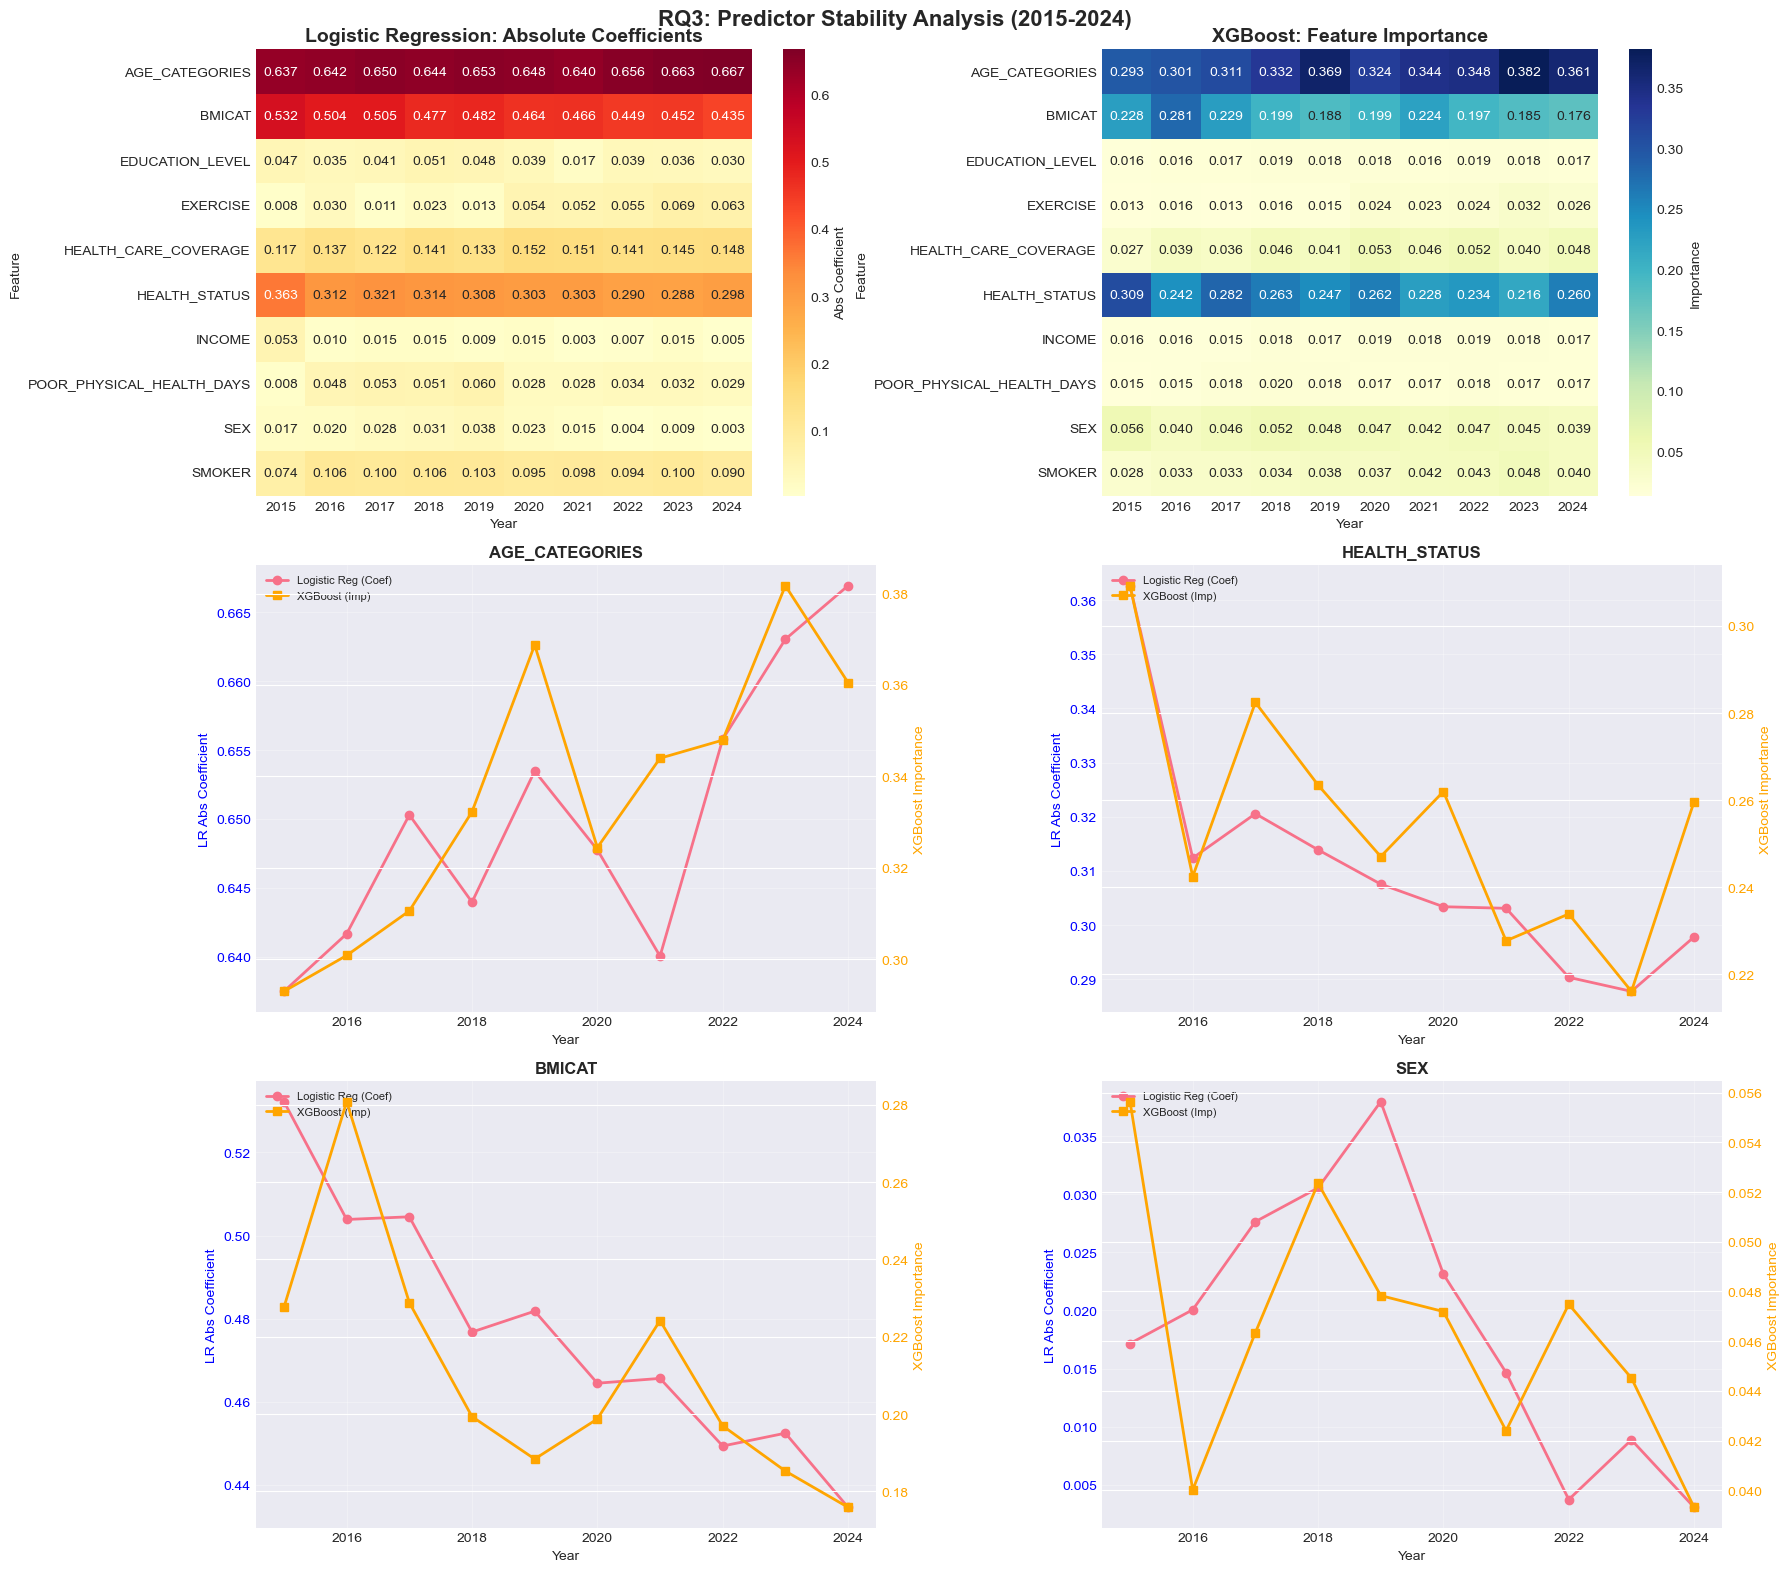

In [9]:
def plot_predictor_stability(lr_df: pd.DataFrame, xgb_df: pd.DataFrame, output_path: str = None):
    """
    Visualize predictor stability over time.
    """
    fig, axes = plt.subplots(3, 2, figsize=(18, 16))
    fig.suptitle(
        "RQ3: Predictor Stability Analysis (2015-2024)",
        fontsize=16,
        fontweight="bold",
    )
    
    # Top 4 features by avg importance (3x2 grid has 6 subplots: 2 heatmaps + 4 feature plots)
    top_features = (
        xgb_df.groupby("Feature")["Importance"]
        .mean()
        .sort_values(ascending=False)
        .head(4)
        .index.tolist()
    )
    
    # Plot 1: LR Coefficients Heatmap
    ax1 = axes[0, 0]
    lr_pivot = lr_df.pivot(index="Feature", columns="Year", values="Abs_Coefficient")
    sns.heatmap(
        lr_pivot,
        annot=True,
        fmt=".3f",
        cmap="YlOrRd",
        ax=ax1,
        cbar_kws={"label": "Abs Coefficient"},
    )
    ax1.set_title("Logistic Regression: Absolute Coefficients", fontsize=14, fontweight="bold")
    
    # Plot 2: XGB Importance Heatmap
    ax2 = axes[0, 1]
    xgb_pivot = xgb_df.pivot(index="Feature", columns="Year", values="Importance")
    sns.heatmap(
        xgb_pivot,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        ax=ax2,
        cbar_kws={"label": "Importance"},
    )
    ax2.set_title("XGBoost: Feature Importance", fontsize=14, fontweight="bold")
    
    # Plots 3-7: Top 5 features line plots
    # Flatten axes for easier indexing
    axes_flat = axes.flatten()
    
    for idx, feature in enumerate(top_features):
        ax = axes_flat[idx + 2]  # Skip first 2 plots (heatmaps)
        
        # LR
        lr_feature = lr_df[lr_df["Feature"] == feature]
        ax.plot(
            lr_feature["Year"],
            lr_feature["Abs_Coefficient"],
            marker="o",
            label="Logistic Reg (Coef)",
            linewidth=2,
        )
        
        # XGB
        xgb_feature = xgb_df[xgb_df["Feature"] == feature]
        ax_twin = ax.twinx()
        ax_twin.plot(
            xgb_feature["Year"],
            xgb_feature["Importance"],
            marker="s",
            color="orange",
            label="XGBoost (Imp)",
            linewidth=2,
        )
        
        ax.set_xlabel("Year", fontsize=10)
        ax.set_ylabel("LR Abs Coefficient", fontsize=10, color="blue")
        ax_twin.set_ylabel("XGBoost Importance", fontsize=10, color="orange")
        ax.set_title(f"{feature}", fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="y", labelcolor="blue")
        ax_twin.tick_params(axis="y", labelcolor="orange")
        
        # Combined legend
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax_twin.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
    
    # Hide unused subplots if < 5 features
    for idx in range(len(top_features) + 2, len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    plt.tight_layout()
    
    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_predictor_stability(lr_df, xgb_df, REPORTS_DIR / "rq3_predictor_stability.png")

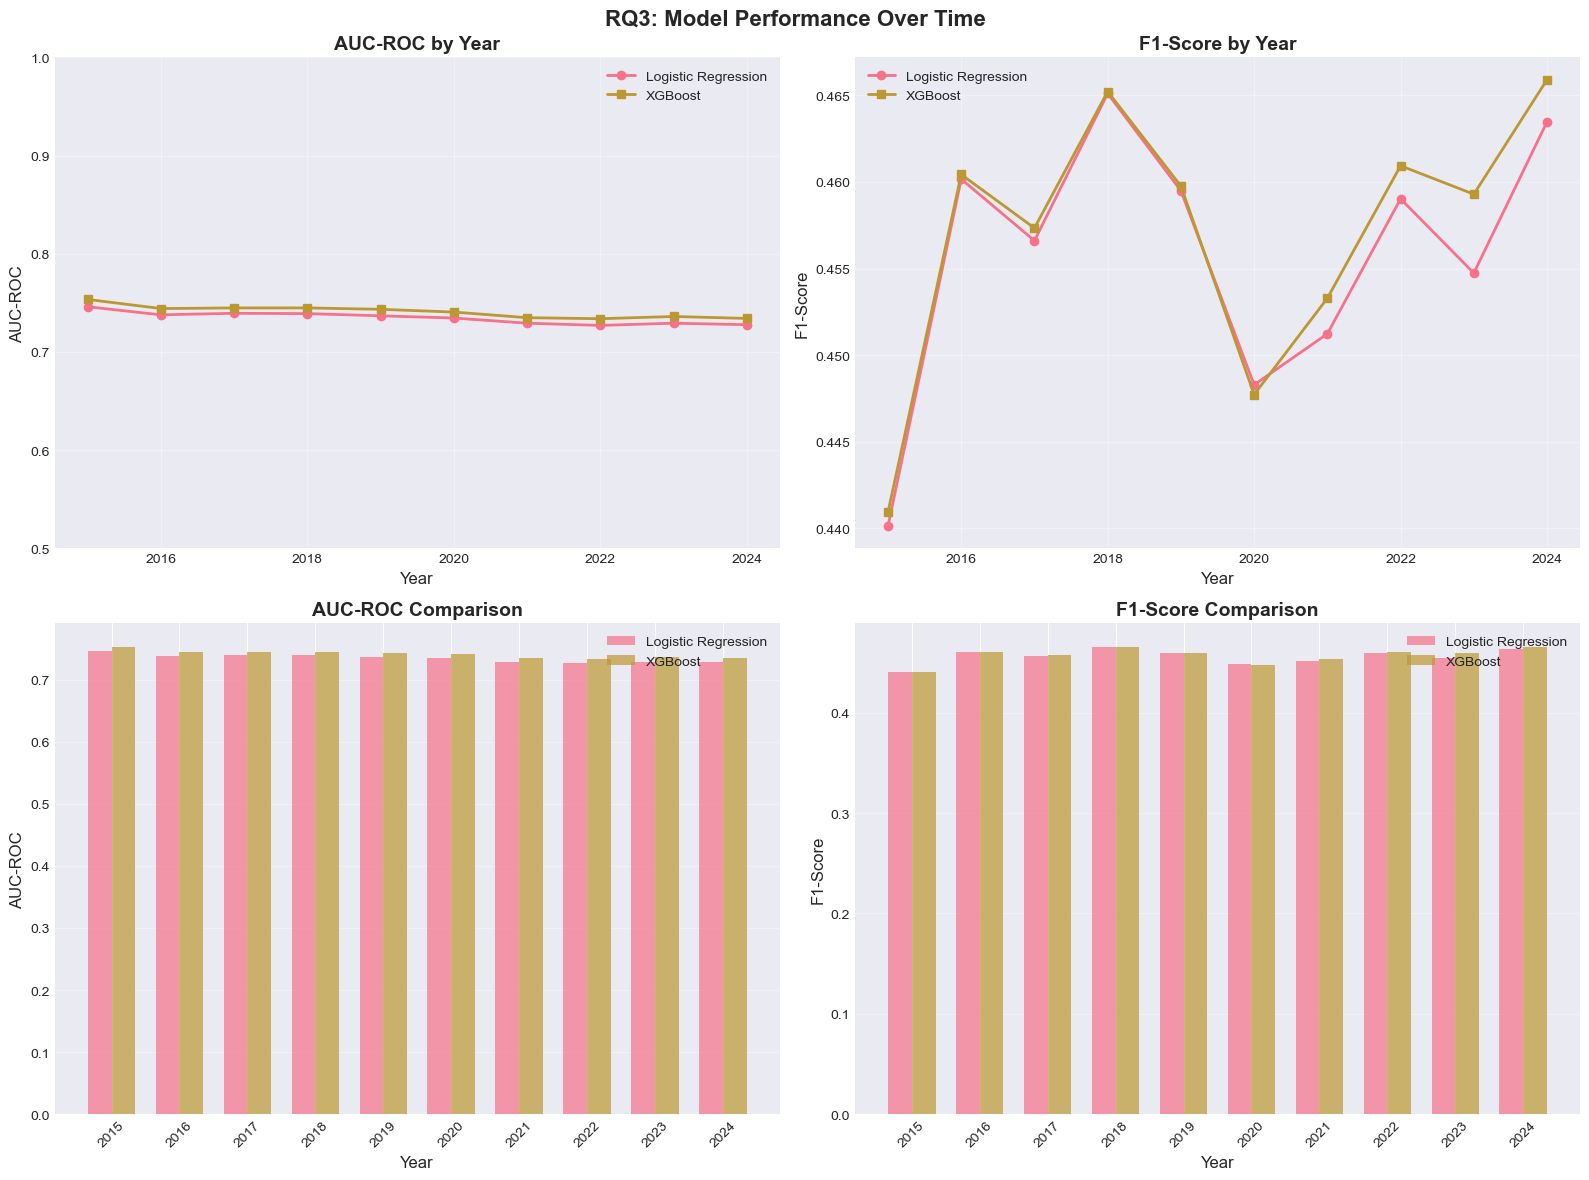

In [10]:
def plot_model_performance(
    logistic_results: list, xgb_results: list, output_path: str = None
):
    """
    Visualize model performance over time.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("RQ3: Model Performance Over Time", fontsize=16, fontweight="bold")
    
    years_lr = [r["year"] for r in logistic_results]
    auc_lr = [r["auc"] for r in logistic_results]
    f1_lr = [r["f1"] for r in logistic_results]
    
    years_xgb = [r["year"] for r in xgb_results]
    auc_xgb = [r["auc"] for r in xgb_results]
    f1_xgb = [r["f1"] for r in xgb_results]
    
    # Plot 1: AUC over time
    ax1 = axes[0, 0]
    ax1.plot(years_lr, auc_lr, marker="o", label="Logistic Regression", linewidth=2)
    ax1.plot(years_xgb, auc_xgb, marker="s", label="XGBoost", linewidth=2)
    ax1.set_xlabel("Year", fontsize=12)
    ax1.set_ylabel("AUC-ROC", fontsize=12)
    ax1.set_title("AUC-ROC by Year", fontsize=14, fontweight="bold")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0.5, 1.0])
    
    # Plot 2: F1 over time
    ax2 = axes[0, 1]
    ax2.plot(years_lr, f1_lr, marker="o", label="Logistic Regression", linewidth=2)
    ax2.plot(years_xgb, f1_xgb, marker="s", label="XGBoost", linewidth=2)
    ax2.set_xlabel("Year", fontsize=12)
    ax2.set_ylabel("F1-Score", fontsize=12)
    ax2.set_title("F1-Score by Year", fontsize=14, fontweight="bold")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: AUC bar comparison
    ax3 = axes[1, 0]
    x_pos = np.arange(len(years_lr))
    width = 0.35
    ax3.bar(x_pos - width / 2, auc_lr, width, label="Logistic Regression", alpha=0.7)
    ax3.bar(x_pos + width / 2, auc_xgb, width, label="XGBoost", alpha=0.7)
    ax3.set_xlabel("Year", fontsize=12)
    ax3.set_ylabel("AUC-ROC", fontsize=12)
    ax3.set_title("AUC-ROC Comparison", fontsize=14, fontweight="bold")
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(years_lr, rotation=45)
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis="y")
    
    # Plot 4: F1 bar comparison
    ax4 = axes[1, 1]
    ax4.bar(x_pos - width / 2, f1_lr, width, label="Logistic Regression", alpha=0.7)
    ax4.bar(x_pos + width / 2, f1_xgb, width, label="XGBoost", alpha=0.7)
    ax4.set_xlabel("Year", fontsize=12)
    ax4.set_ylabel("F1-Score", fontsize=12)
    ax4.set_title("F1-Score Comparison", fontsize=14, fontweight="bold")
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(years_lr, rotation=45)
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis="y")
    
    plt.tight_layout()
    
    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_model_performance(logistic_results, xgb_results, REPORTS_DIR / "rq3_model_performance.png")

In [11]:
# Predictor variation stats
stability_stats = []
for feature in feature_cols:
    feature_data = xgb_df[xgb_df["Feature"] == feature]
    stability_stats.append(
        {
            "Feature": feature,
            "Mean_Importance": feature_data["Importance"].mean(),
            "Std_Importance": feature_data["Importance"].std(),
            "CV": (
                feature_data["Importance"].std()
                / feature_data["Importance"].mean()
                if feature_data["Importance"].mean() > 0
                else 0
            ),
            "Min": feature_data["Importance"].min(),
            "Max": feature_data["Importance"].max(),
            "Range": feature_data["Importance"].max() - feature_data["Importance"].min(),
        }
    )

stability_df = pd.DataFrame(stability_stats).sort_values("CV", ascending=False)
stability_df.to_csv("../reports/rq3_predictor_variability.csv", index=False)

logging.info("Predictor Variability (Coefficient of Variation):")
logging.info(stability_df[["Feature", "Mean_Importance", "CV"]].to_string())

# Conclusion
sig_comparisons = len(stability_df[stability_df["CV"] > 0.3])
logging.info("\n" + "=" * 70)
logging.info("CONCLUSION")
logging.info("=" * 70)
logging.info(f"\n• Predictors analyzed: {len(feature_cols)}")
logging.info(f"• Predictors with high variation (CV > 0.3): {sig_comparisons}")
logging.info(f"• Average model AUC (XGBoost): {performance_df['XGB_AUC'].mean():.4f}")
logging.info(f"• AUC range: {performance_df['XGB_AUC'].min():.4f} - {performance_df['XGB_AUC'].max():.4f}")

high_variation = stability_df[stability_df["CV"] > 0.3]
if len(high_variation) > 0:
    logging.info(f"\n✓ REJECT H₃₀: Evidence of significant predictor variation")
    logging.info(f"\nPredictors with HIGH variation:")
    logging.info(high_variation[["Feature", "CV"]].to_string(index=False))
else:
    logging.info(f"\n✗ FAIL TO REJECT H₃₀: Predictors show consistent strength")
logging.info("=" * 70)

2026-02-04 23:20:46 - INFO - Predictor Variability (Coefficient of Variation):
2026-02-04 23:20:46 - INFO -                      Feature  Mean_Importance        CV
1                   EXERCISE         0.020168  0.318068
7       HEALTH_CARE_COVERAGE         0.042770  0.182797
2                     SMOKER         0.037706  0.158780
0                     BMICAT         0.210599  0.146231
6                        SEX         0.046309  0.110342
8              HEALTH_STATUS         0.254366  0.107818
5             AGE_CATEGORIES         0.336402  0.087789
9  POOR_PHYSICAL_HEALTH_DAYS         0.017050  0.085614
3                     INCOME         0.017244  0.072195
4            EDUCATION_LEVEL         0.017387  0.057441
2026-02-04 23:20:46 - INFO - 
2026-02-04 23:20:46 - INFO - CONCLUSION
2026-02-04 23:20:46 - INFO - ======================================================================
2026-02-04 23:20:46 - INFO - 
• Predictors analyzed: 10
2026-02-04 23:20:46 - INFO - • Predictors with hig